# <span style='color:#ffbf00'>**Introduction**</span>

This notebook analyzes a real `Brazilian e-commerce` dataset from `Olist Store`, covering 100,000 orders placed between 2016 and 2018 across multiple marketplaces in Brazil.  
Olist is Brazil's largest department store platform, connecting small businesses nationwide to customers through a single contract.  
The dataset includes comprehensive order information such as pricing, payment methods, shipping performance, customer locations, product details, and customer reviews.   
All data has been anonymized to protect privacy.  
This analysis explores customer behavior, sales patterns, shipping efficiency, product performance, and factors affecting customer satisfaction to uncover actionable insights for e-commerce optimization.  
For more details about the dataset, see: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

# <span style='color:#ffbf00'>**Loading the data**</span>

In [ ]:
# Importing libraries 

import numpy as np
import pandas as pd

import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go

# Convert interactive plots to PNG format for GitHub rendering
import plotly.io as pio
pio.renderers.default = "png"


#### <span style='color:#ffdc73'>**Data Structure & Merging**</span>

In [4]:
# Importing the data
path = 'Brazilian E-Commerce Public Dataset by Olist'
customers = pd.read_csv(f"{path}\olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{path}\olist_geolocation_dataset.csv")
order_items = pd.read_csv(f"{path}\olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{path}\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{path}\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{path}\olist_orders_dataset.csv")
products = pd.read_csv(f"{path}\olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}\olist_sellers_dataset.csv")
product_translation = pd.read_csv(f"{path}\product_category_name_translation.csv")

In [5]:
# Merge customers with orders
df = orders.merge(customers, on="customer_id", how="left")

# Add order items
df = df.merge(order_items, on="order_id", how="left")

# Add products info
df = df.merge(products, on="product_id", how="left")

# # Add product category translation
# df = df.merge(product_translation, on="product_category_name", how="left")

# Add sellers info
df = df.merge(sellers[["seller_id","seller_city","seller_state"]], on="seller_id", how="left")

# Add payments info
df = df.merge(order_payments, on="order_id", how="left")

# Add reviews info
df = df.merge(order_reviews[["order_id",'review_score']], on="order_id", how="left")

df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,maua,SP,1.0,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,maua,SP,3.0,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,maua,SP,2.0,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,belo horizonte,SP,1.0,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,guariba,SP,1.0,credit_card,3.0,179.12,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,40.0,10.0,40.0,tupa,SP,1.0,credit_card,3.0,195.00,4.0
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,32.0,90.0,22.0,sao paulo,SP,1.0,credit_card,5.0,271.01,5.0
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,ilicinea,MG,1.0,credit_card,4.0,441.16,2.0
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,ilicinea,MG,1.0,credit_card,4.0,441.16,2.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

# <span style='color:#ffbf00'>**Data Cleaning**</span>

In [7]:
# Converting date columns to datetime format

date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']

df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [8]:
# Function to shorten any ID column (first 3 + '_' + last 3 characters) (for readability)
def shorten_id_columns(dataframe):
    id_columns = [col for col in dataframe.columns if 'id' in col.lower()]
    for col in id_columns:
        dataframe[col] = dataframe[col].astype(str).apply(lambda x: x[:3] + '_' + x[-3:] if len(x) > 6 else x)
    return dataframe

# Apply to your dataframe
df = shorten_id_columns(df)
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e48_af7,9ef_28d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c3_bff,3149,...,19.0,8.0,13.0,maua,SP,1.0,credit_card,1.0,18.12,4.0
1,e48_af7,9ef_28d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c3_bff,3149,...,19.0,8.0,13.0,maua,SP,3.0,voucher,1.0,2.00,4.0
2,e48_af7,9ef_28d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c3_bff,3149,...,19.0,8.0,13.0,maua,SP,2.0,voucher,1.0,18.59,4.0
3,53c_451,b08_7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af0_231,47813,...,19.0,13.0,19.0,belo horizonte,SP,1.0,boleto,1.0,141.46,4.0
4,477_65d,41c_089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a6_0e8,75265,...,24.0,19.0,21.0,guariba,SP,1.0,credit_card,3.0,179.12,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,639_bd8,1fc_7a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da6_660,11722,...,40.0,10.0,40.0,tupa,SP,1.0,credit_card,3.0,195.00,4.0
119139,83c_1ab,1aa_c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737_b30,45920,...,32.0,90.0,22.0,sao paulo,SP,1.0,credit_card,5.0,271.01,5.0
119140,11c_b62,b33_7c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,509_43c,28685,...,20.0,20.0,20.0,ilicinea,MG,1.0,credit_card,4.0,441.16,2.0
119141,11c_b62,b33_7c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,509_43c,28685,...,20.0,20.0,20.0,ilicinea,MG,1.0,credit_card,4.0,441.16,2.0


In [9]:
# Truncate all string columns to first 15 characters for better visualization

def truncate_strings(df, length=15):
    for col in df.select_dtypes(include='object'):
        df[col] = df[col].str[:length]
    return df

df = truncate_strings(df)

#### <span style='color:#ffdc73'>**Duplicated values**</span>

In [10]:
# Duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

421
0


#### <span style='color:#ffdc73'>**Missing values**</span>

In [11]:
# Null values
df.isna().sum().sort_values(ascending=False)

order_delivered_customer_date    3411
product_photos_qty               2534
product_description_lenght       2534
product_name_lenght              2534
product_category_name            2534
order_delivered_carrier_date     2082
review_score                      997
product_weight_g                  851
product_length_cm                 851
product_height_cm                 851
seller_city                       831
price                             831
shipping_limit_date               831
freight_value                     831
seller_state                      831
order_approved_at                 176
payment_installments                3
payment_value                       3
payment_type                        3
payment_sequential                  3
order_id                            0
product_id                          0
seller_id                           0
customer_state                      0
customer_unique_id                  0
customer_id                         0
order_purcha

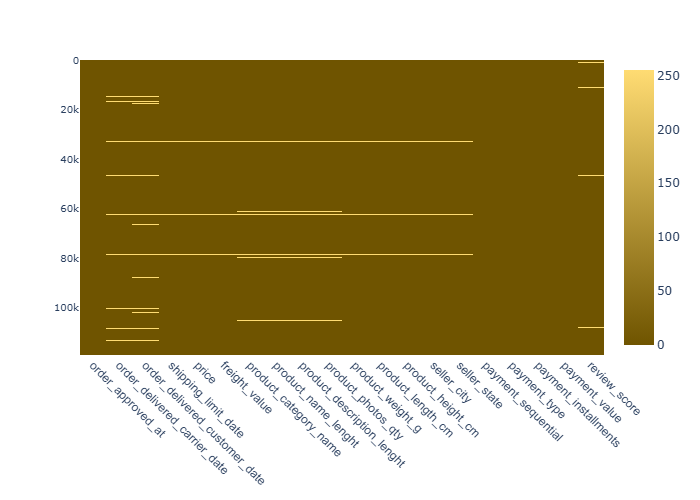

In [12]:
fig = px.imshow(df[df.columns[df.isna().any()]].isna(), color_continuous_scale=["#6f5400", "#ffdc73"])

fig.update_xaxes(tickangle=45, tickfont=dict(size=12, family="Arial"))
fig.update_yaxes(tickfont=dict(size=10))

fig.update_layout(height=800, width=1200)

fig.show()


# <span style='color:#ffbf00'>**Exploratory Data Analysis**</span>

#### <span style='color:#ffdc73'>**Overall Order & Sales**</span>

In [13]:
# How many unique orders, customers, and sellers are in the dataset?

print(f"There are {df['order_id'].nunique()} orders")
print(f"There are {df['customer_unique_id'].nunique()} customers")
print(f"There are {df['seller_id'].nunique()} sellers")

There are 99140 orders
There are 95809 customers
There are 3096 sellers


In [14]:
# What is the total value of all sales and freight?

print(f"Total value of sales: {df['payment_value'].sum():,.2f}")
print(f"Total value of freight: {df['freight_value'].sum():,.2f} ")

Total value of sales: 20,518,016.53
Total value of freight: 2,362,651.90 


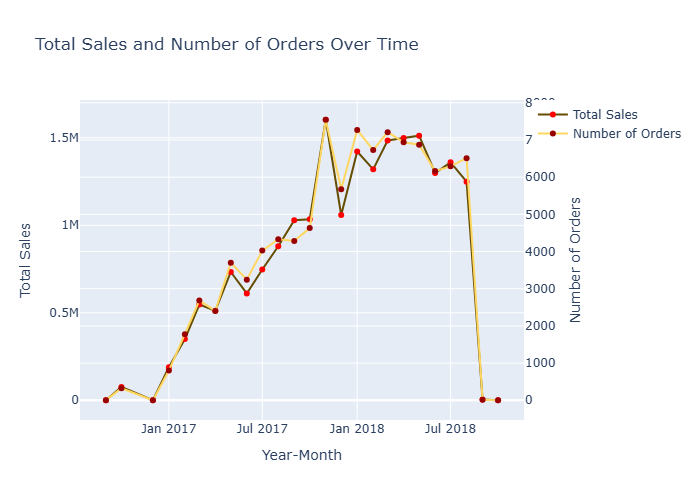

In [15]:
# How do the number of orders and sales values trend over time (e.g., by month or year)?

df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_trends = df.groupby('year_month').agg(total_sales=('payment_value', 'sum'), 
                                              num_orders=('order_id', 'nunique')).reset_index()
monthly_trends['year_month'] = monthly_trends['year_month'].astype(str)

fig = go.Figure()
fig.add_trace(go.Scatter(x=monthly_trends['year_month'], y=monthly_trends['total_sales'], 
                         mode='lines+markers', name='Total Sales',
                         line=dict(color="#654c00"), marker=dict(color="#FF0000")))
                         
fig.add_trace(go.Scatter(x=monthly_trends['year_month'], y=monthly_trends['num_orders'],  
                         mode='lines+markers', name='Number of Orders', yaxis='y2',  
                         line=dict(color="#ffd760"), marker=dict(color='#990000')))

fig.update_layout(
    title='Total Sales and Number of Orders Over Time',
    xaxis_title='Year-Month', yaxis_title='Total Sales',
    yaxis2=dict(title='Number of Orders', overlaying='y', side='right'),
    width=1200, height=500)
fig.show()

Total sales and order volume demonstrate consistent parallel growth from October 2016 through October 2018, indicating business expansion was driven by increased transaction frequency.   
Both metrics show similar seasonal patterns with temporary dips in early 2018. The strong correlation suggests revenue growth was primarily volume-based rather than price-based during this period.

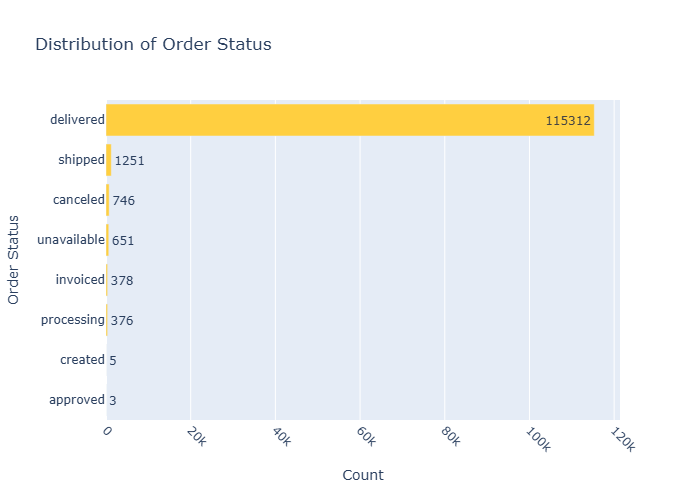

In [16]:
# What is the distribution of `order_status` values?

df0 =df['order_status'].value_counts().reset_index()\
    .sort_values('count', ascending=True)

fig = px.bar(df0, x='count', y='order_status',
             orientation='h',title='Distribution of Order Status',
             color_discrete_sequence=["#ffcf40"],
             width=1200, text='count' )
fig.update_xaxes(tickangle=45)
fig.update_layout(xaxis_title='Count', yaxis_title='Order Status',)
fig.show()

`Delivered` is the most common order status.

#### <span style='color:#ffdc73'>**Customer & Geographical Insights**</span> 

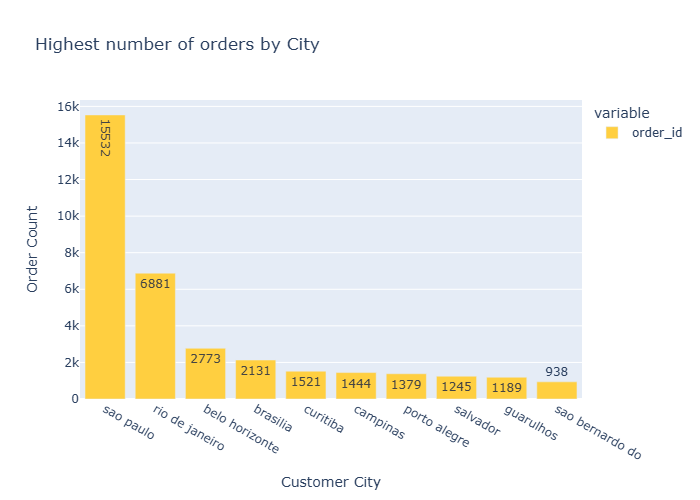

In [17]:
# Which customer `city` have the highest number of orders?
df0 = df.groupby('customer_city')['order_id'].nunique().nlargest(10)

fig = px.bar(df0, title='Highest number of orders by City',
       color_discrete_sequence=["#ffcf40"], text='value', width=1200)
fig.update_layout(xaxis_title='Customer City', yaxis_title='Order Count',)
fig.show()

`Sao paulo` have the highest number of orders.

In [18]:
# How many customers have a `customer_unique_id` that appears more than once (i.e., repeat customers)?

repeat = df['customer_unique_id'].value_counts().to_frame()
repeat = repeat[repeat['count'] > 1].count()
print('There are', repeat['count'], 'Customers that appears more than once.')

There are 14643 Customers that appears more than once.


In [19]:
# Average number of orders per unique customer
print('Average number of orders per unique customer: ', df.groupby('customer_unique_id')['order_id'].nunique().mean().round(2))

Average number of orders per unique customer:  1.04


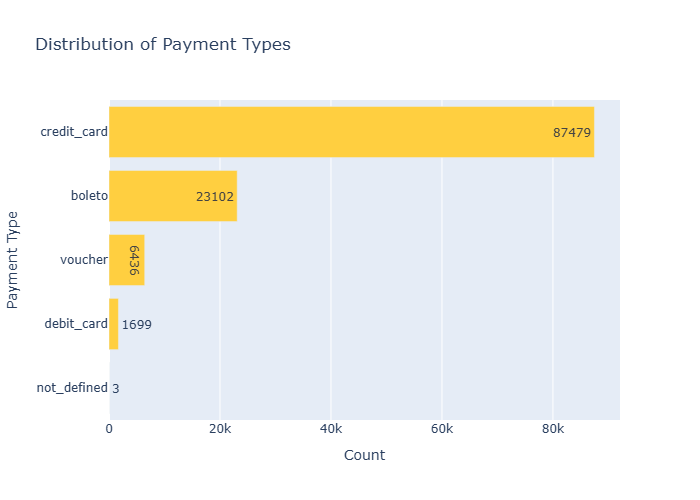

In [20]:
# What is the distribution of `payment_type`?

df0 = df['payment_type'].value_counts().reset_index().sort_values('count', ascending=True)
df0.columns = ['payment_type', 'count']
fig = px.bar(df0, x='count', y='payment_type', 
             orientation='h', title='Distribution of Payment Types', width=1200,
             color_discrete_sequence=["#ffcf40"], text='count')
fig.update_layout(xaxis_title='Count', yaxis_title='Payment Type',)
fig.show()

Customers tend to pay with `credit cards`.

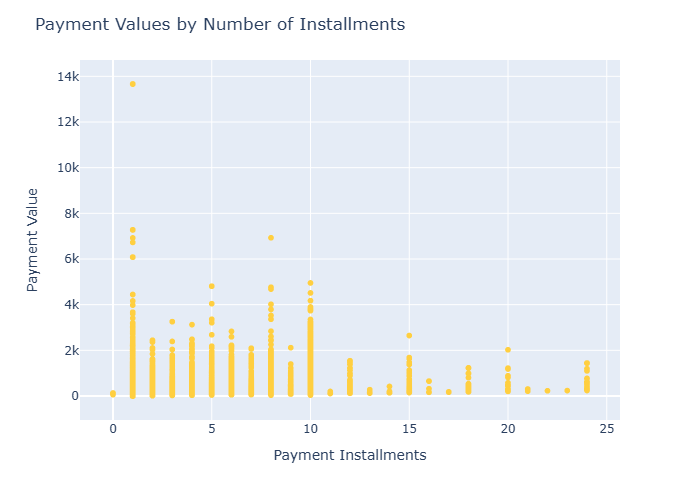

In [21]:
# How does `payment_value` relate to the number of `payment_installments`?

fig = px.scatter(df,y='payment_value',x='payment_installments', 
                 color_discrete_sequence=["#ffcf40"], width=1200)
fig.update_layout(xaxis_title='Payment Installments', yaxis_title='Payment Value',
                  title='Payment Values by Number of Installments')
fig.show()

Payment values generally decrease as the number of installments increases, suggesting customers use more installments for lower-value purchases.  
Most transactions occur with fewer than 10 installments, while higher installment counts (15+) show minimal payment values. This indicates installment financing is primarily used for affordable purchases rather than high-value items.

#### <span style='color:#ffdc73'>**Seller & Fulfillment Performance**</span>

Resorting to unclean kill browser.


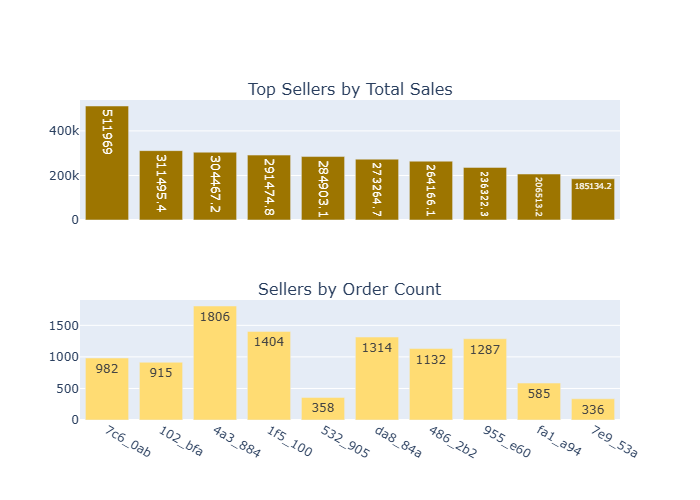

In [22]:
# Who are the top 10 sellers by total sales and total number of orders?

from plotly.subplots import make_subplots

top_sellers = df.groupby('seller_id').agg(total_sales=('payment_value', 'sum'), order_count=('order_id', 'nunique'))\
                .sort_values('total_sales', ascending=False)\
                .head(10).reset_index().round(1)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=('Top Sellers by Total Sales', 'Sellers by Order Count'))

fig.add_trace(go.Bar(x=top_sellers['seller_id'], y=top_sellers['total_sales'], marker_color="#9d7500",
                      text=top_sellers['total_sales']), row=1, col=1)
fig.add_trace(go.Bar(x=top_sellers['seller_id'], y=top_sellers['order_count'], marker_color="#ffdc73",
                      text=top_sellers['order_count']), row=2, col=1)
fig.update_layout(height=600,width=1200, showlegend=False)
fig.show()

The top sellers' order counts don't directly correlate with their sales rankings, revealing different business models.  
Some sellers achieve high sales with fewer orders (indicating high-value transactions), while others process more orders for lower individual values. This suggests diverse sales strategies exist among top performers, with some focusing on premium products and others on volume transactions.

In [23]:
# How long does it take on average for an order to be delivered?
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
avg_delivery_time = df['delivery_time_days'].mean()
print(f"\nAverage delivery time: {avg_delivery_time:.2f} days")


Average delivery time: 12.02 days


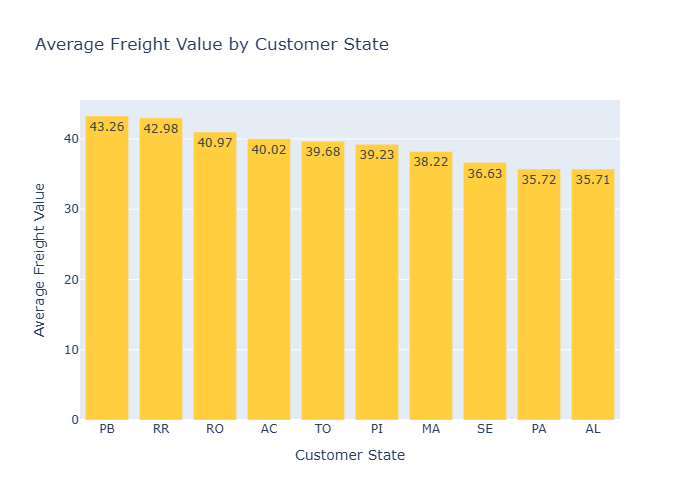

In [24]:
# Does the distance between the seller and customer cities affect the `freight_value` or delivery time?

# Average freight value by customer state
fig = px.bar(df.groupby('customer_state')['freight_value'].mean().nlargest(10).reset_index().round(2), 
             x='customer_state', y='freight_value',
             title='Average Freight Value by Customer State',
             labels={'customer_state': 'Customer State', 'freight_value': 'Average Freight Value'},
             color_discrete_sequence=["#ffcf40"], text='freight_value', width=1200)
fig.show()

Top customer states by average freight value are: `PB`, and `RR`.

#### <span style='color:#ffdc73'>**Product & Pricing**</span>

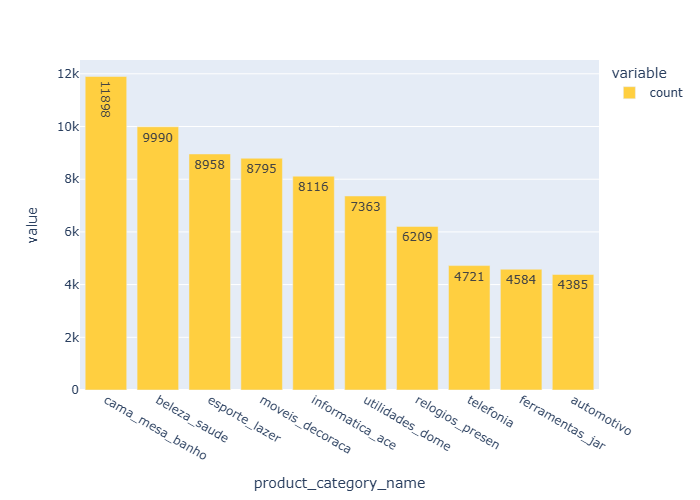

In [25]:
## What are the top 10 most popular `product_category_name`s by number of orders?

df0 = df['product_category_name'].value_counts().nlargest(10)
px.bar(df0, color_discrete_sequence=["#ffcf40"], text='value',width=1200)

Top popular product category name by number of orders: `cama mesa banho`, and `beleza saude`.

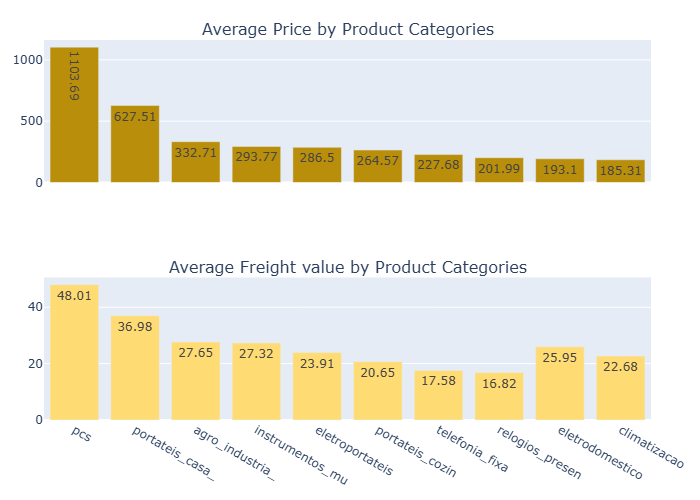

In [26]:
# What is the average `price` and `freight_value` for the top product categories?

df0 = df.groupby('product_category_name').agg(
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).nlargest(10, 'avg_price').reset_index().round(2)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=('Average Price by Product Categories', 'Average Freight value by Product Categories'))

fig.add_trace(go.Bar(x=df0['product_category_name'], y=df0['avg_price'], marker_color="#b98e0a",text=df0['avg_price']), 
              row=1, col=1)
fig.add_trace(go.Bar(x=df0['product_category_name'], y=df0['avg_freight'],marker_color="#ffdc73",text=df0['avg_freight']),
              row=2, col=1)
fig.update_layout(height=600, width=1200, showlegend=False, margin=dict(l=20, r=20, t=40, b=20))
fig.show()

Top average Price and Freight Value for the top product categories are: `pcs`, and `portateis casa`.

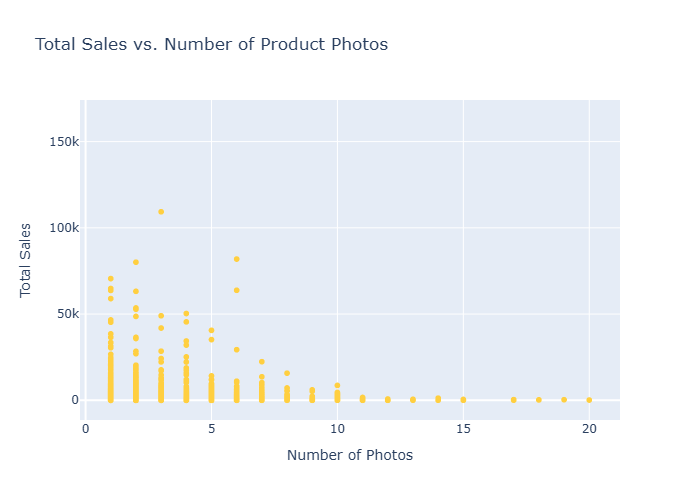

In [27]:
# Is there a relationship between the `sales` or `product_photos_qty` and the number of sales?

df_products_sales = df.groupby('product_id').agg(
    total_sales=('payment_value', 'sum'),
    product_photos_qty=('product_photos_qty', 'first')
).reset_index()


px.scatter(df_products_sales, x='product_photos_qty', y='total_sales',
           title='Total Sales vs. Number of Product Photos',
           labels={'product_photos_qty': 'Number of Photos', 'total_sales': 'Total Sales'},
           color_discrete_sequence=["#ffcf40"], width=1200)


Total sales peak for products with 1-3 photos, then sharply decline as photo count increases.  
Products with moderate photo numbers (5-10) maintain relatively stable sales, while those with many photos (15+) show minimal revenue. This suggests customers prefer products with sufficient but not excessive visual information, and overly documented items may indicate problematic listings or niche products.

#### <span style='color:#ffdc73'>**Customer Feedback**</span>

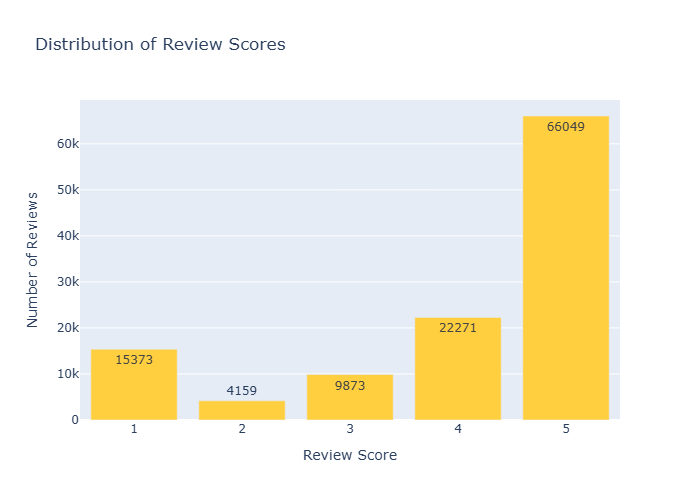

In [28]:
# What is the distribution of `review_score`?

review_counts = df['review_score'].value_counts().sort_index().reset_index()
review_counts.columns = ['review_score', 'count']

fig = px.bar(review_counts, x='review_score', y='count',
             title='Distribution of Review Scores',
             labels={'review_score': 'Review Score', 'count': 'Number of Reviews'},
             text='count', width=1200)
fig.update_traces(marker_color='#ffcf40')
fig.show()

Customers demonstrate extreme rating behavior, overwhelmingly awarding perfect 5-star scores while reserving minimal lower ratings, indicating high satisfaction with polarized feedback patterns.

In [29]:
print('Average review score: ', df['review_score'].mean().round(2))

Average review score:  4.01


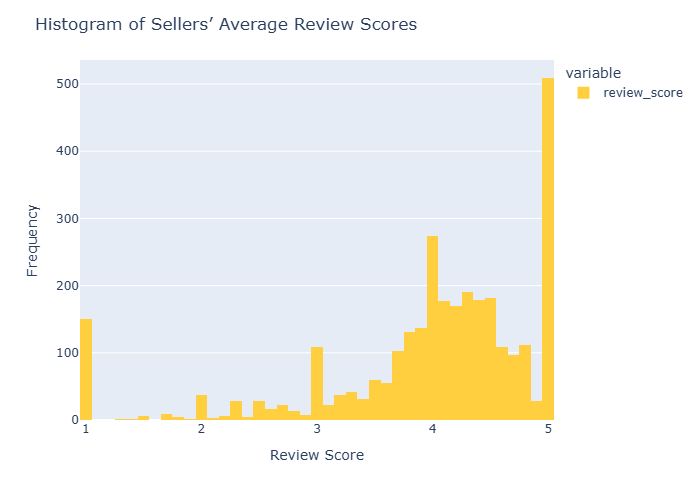

In [30]:
# Do different sellers or product categories receive different average `review_score`s?
df0 = df.groupby('seller_id')['review_score'].mean().round(2)
fig = px.histogram(df0, height=600, width=1200, color_discrete_sequence=["#ffcf40"])
fig.update_layout(xaxis_title='Review Score', yaxis_title='Frequency',
                  title='Histogram of Sellers’ Average Review Scores')
fig.show()

Seller quality demonstrates platform-wide consistency, with most sellers maintaining 4.0-4.5 average ratings.  
Customer satisfaction remains stable across sellers, indicating effective quality control and standardized service delivery that supports marketplace trust and repeat purchases.

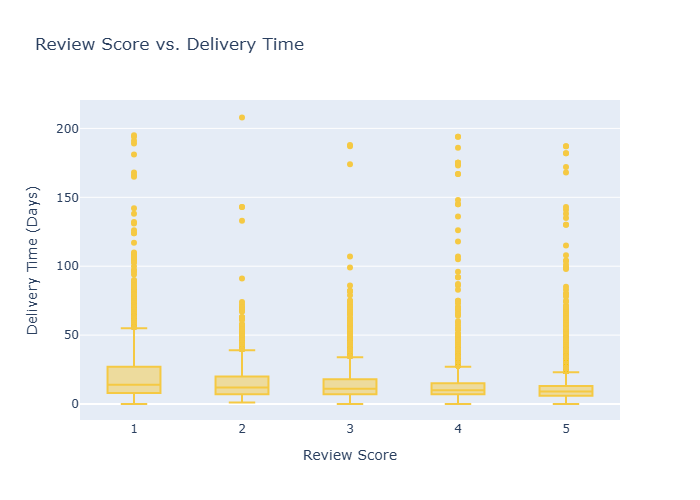

In [31]:
# Is there a relationship between `review_score` and the delivery time? For example, do late deliveries get lower scores?
fig = px.box(df, x='review_score', y='delivery_time_days',
             title='Review Score vs. Delivery Time',
             labels={'review_score': 'Review Score', 'delivery_time_days': 'Delivery Time (Days)'},
             color_discrete_sequence=["#f5c943"])
fig.update_layout(width=1200, height=600)
fig.show()

Delivery time shows minimal correlation with review scores, suggesting customers don't heavily penalize longer shipping periods. Even extended delivery times (150+ days) still receive positive ratings, indicating other factors like product quality dominate satisfaction more than shipping speed.

#### <span style='color:#ffdc73'>**Orders & Sales Trends**</span>

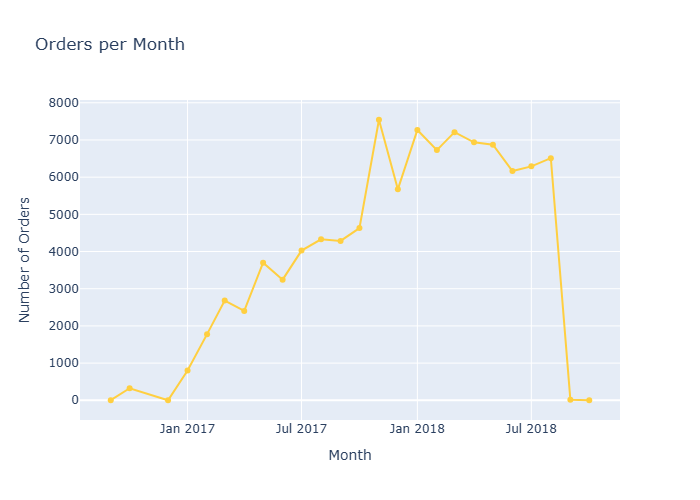

In [32]:
# Orders & Sales Trends

monthly_orders = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()
monthly_orders['order_purchase_timestamp'] = monthly_orders['order_purchase_timestamp'].astype(str)

fig = px.line(monthly_orders, x='order_purchase_timestamp', y='order_id',
              title='Orders per Month',
              labels={'order_purchase_timestamp': 'Month', 'order_id': 'Number of Orders'},
              markers=True,color_discrete_sequence=["#ffcf40"])
fig.update_layout(width=1200, height=500)
fig.show()

The plot shows strong growth momentum, with order volume increasing 7x from late 2016 to late 2018.  
We're experiencing consistent month-over-month expansion, indicating successful customer acquisition and retention strategies that support sustainable revenue growth and market position strengthening.

#### <span style='color:#ffdc73'>**Customer Behavior**</span>

Repeat Customer Rate: 0.28%


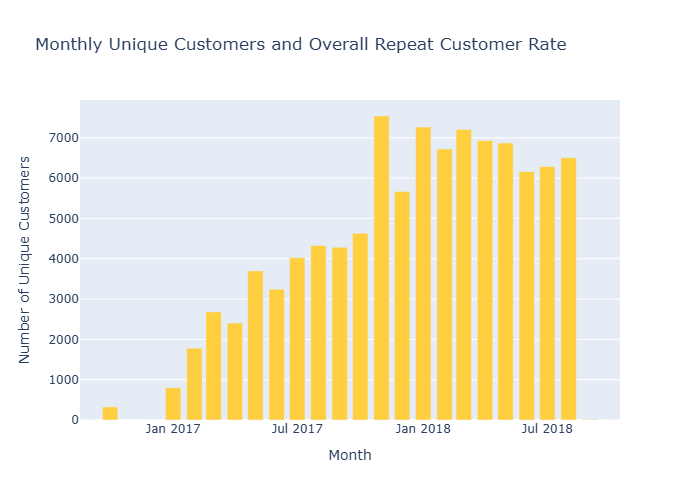

In [33]:
# Monthly Unique Customers and Overall Repeat Customer Rate

unique_customers_month = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['customer_id'].nunique()
repeat_customers = df.groupby('customer_id')['order_id'].nunique()
repeat_rate = (repeat_customers > 1).mean() * 100
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

unique_customers_month = (
    df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['customer_id']
      .nunique()
      .reset_index()
)
unique_customers_month['year_month'] = unique_customers_month['order_purchase_timestamp'].astype(str)
unique_customers_month = unique_customers_month.rename(columns={'customer_id': 'unique_customers'})

fig = px.bar(
    unique_customers_month,
    x='year_month',
    y='unique_customers',
    title='Monthly Unique Customers and Overall Repeat Customer Rate',
    color_discrete_sequence=["#ffcf40"], width=1200)
fig.update_layout(xaxis_title='Month', yaxis_title='Number of Unique Customers')
fig.show()


New customer acquisition shows parallel growth with overall orders, indicating effective market expansion.  
The customer base is expanding steadily while maintaining healthy repeat purchase rates, suggesting balanced growth between acquiring new buyers and nurturing existing customer relationships for sustainable business development.

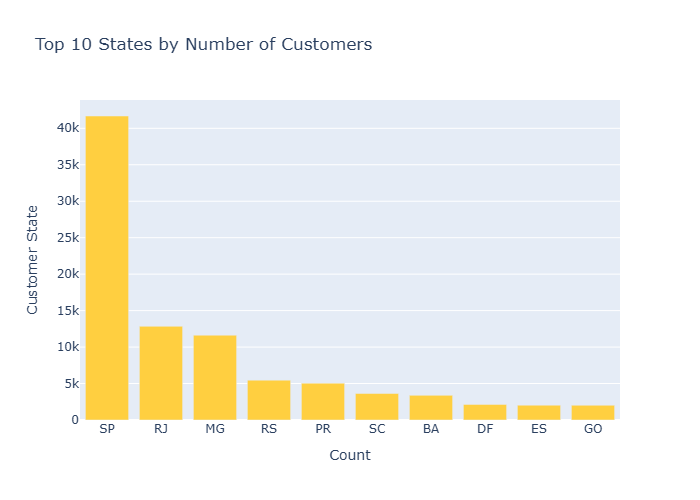

In [34]:
# Top 10 States by Number of Customers

df0 = df.groupby('customer_state')['order_id'].nunique()\
        .sort_values(ascending=False)\
        .head(10)\
        .reset_index()\
        .rename(columns={'order_id': 'count'})

fig = px.bar(df0, y='count', x='customer_state',
             color_discrete_sequence=["#ffcf40"],
             title="Top 10 States by Number of Customers",
             width=1200)

fig.update_layout(xaxis_title='Count', yaxis_title='Customer State')

fig.show()


`SP` dominates with 40K customers, followed by `RJ` (15K) and `MG` (13K).  
`SP` has nearly 3x more customers than second place, establishing clear regional market leadership.

#### <span style='color:#ffdc73'>**Product Performance**</span>

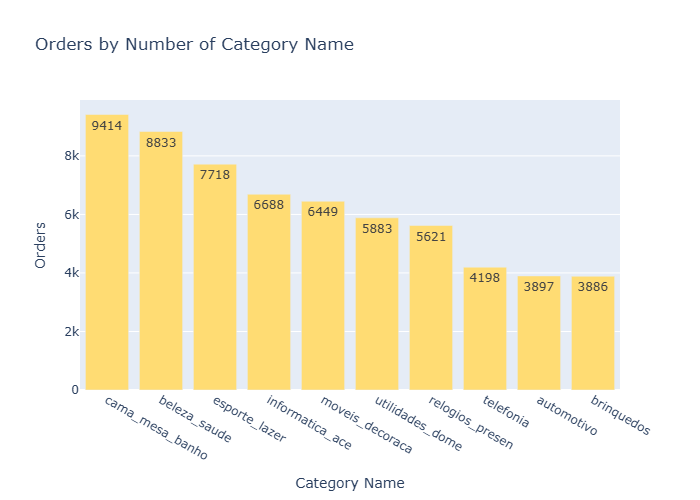

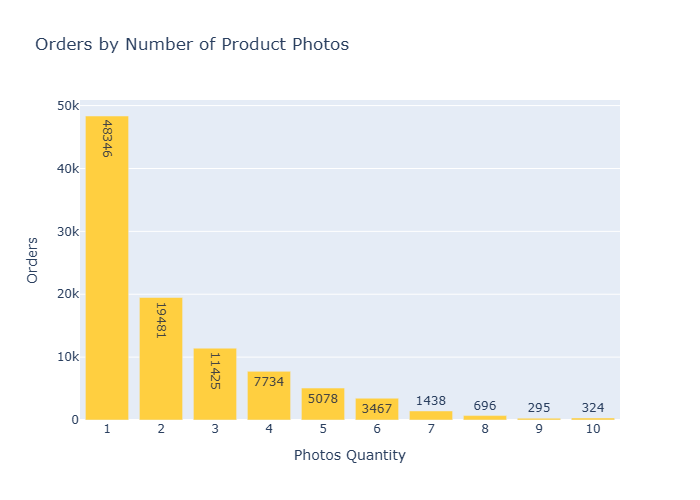

In [35]:
# Product Performance

top_categories = df.groupby('product_category_name')['order_id'].nunique().nlargest(10).reset_index()
photo_corr = df.groupby('product_photos_qty')['order_id'].nunique().astype(int).nlargest(10).reset_index()

fig = px.bar(top_categories, x='product_category_name', y='order_id',
             title='Orders by Number of Category Name',
             labels={'product_category_name': 'Category Name', 'order_id': 'Orders'},
             text='order_id', width=1200)
fig.update_traces(marker_color='#ffdc73')
fig.show();
fig = px.bar(photo_corr, x='product_photos_qty', y='order_id',
             title='Orders by Number of Product Photos',
             labels={'product_photos_qty': 'Photos Quantity', 'order_id': 'Orders'},
             text='order_id', width=1200)
fig.update_traces(marker_color='#ffcf40')
fig.update_xaxes(tickmode='linear', dtick=1)
fig.show()

The first chart shows that `cama mesa banho` is the most popular product category with 9,414 orders, followed by `beleza saude`, and `esporte lazer`, while the top 3 categories account for about 26% of all orders.  
The second chart reveals that most products (48,346 orders) have only 1 photo, with a sharp decline as photo quantity increases, suggesting sellers typically use minimal product images.

#### <span style='color:#ffdc73'>**Seller Performance**</span>

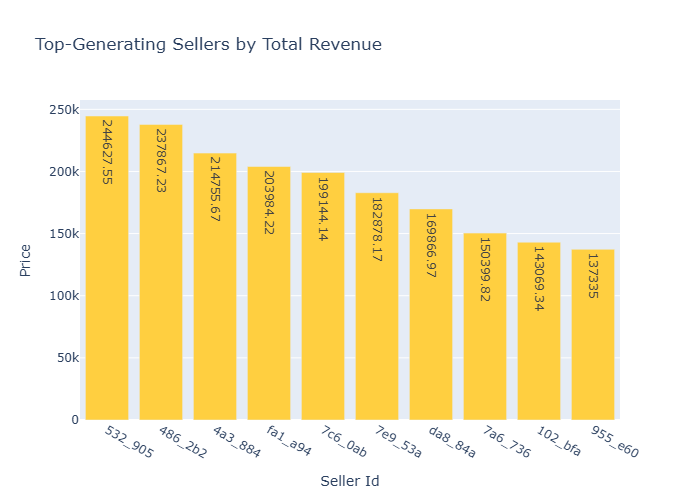

In [36]:
# Which sellers generate the highest revenue?

df0 = df.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(df0, x='seller_id', y='price',
             title='Top-Generating Sellers by Total Revenue',
             labels={'seller_id': 'Seller Id', 'price': 'Price'},
             text='price', width=1200)
fig.update_traces(marker_color='#ffcf40')
fig.show();


Top generating sellers by total revenue are: `532_905`, and `486_2b2`.

#### <span style='color:#ffdc73'>**Payment Analysis**</span>

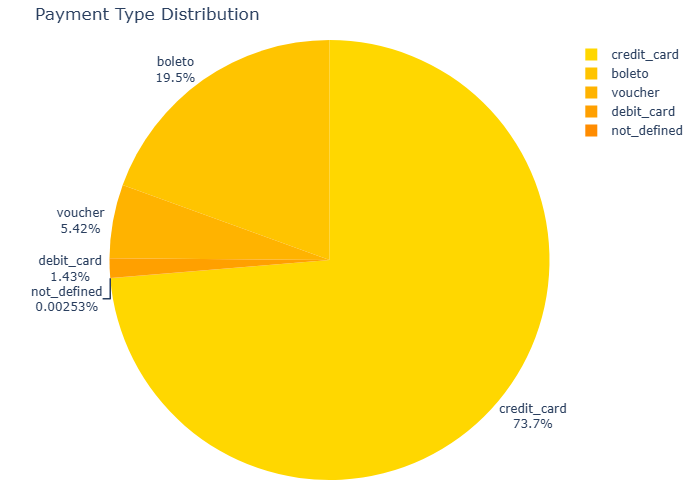

In [37]:
# Payment Analysis

payment_types = df['payment_type'].value_counts().reset_index()

fig = px.pie(payment_types, values='count', names='payment_type', title='Payment Type Distribution', hole=0,
             color_discrete_sequence=['#FFD700', '#FFC400', '#FFB300', '#FFA000', '#FF8C00'])
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(width=800, height=500, margin=dict(l=20, r=20, t=40, b=20))
fig.show()

`Credit cards `dominate as the preferred payment method at 73.7%, followed by `boleto` (bank slip) at 19.5%, while `vouchers` and `debit cards` represent smaller shares at 5.42% and 1.43% respectively.

#### <span style='color:#ffdc73'>**Delivery Performance**</span>

In [38]:
# Delivery Performance

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delay'] = df['delivery_days'] - df['estimated_days']

late_orders = (df['delay'] > 0).mean() * 100
print(f"Late Delivery Rate: {late_orders:.2f}%")


Late Delivery Rate: 7.12%


#### <span style='color:#ffdc73'>**Review Analysis**</span>

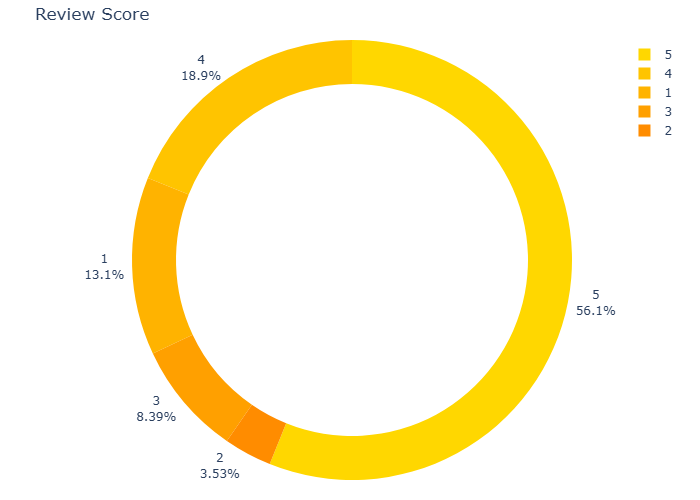

In [39]:
# Review Score

review_dist = (df['review_score'].value_counts(normalize=True) * 100).round(2).reset_index()

fig = px.pie(review_dist, values='proportion', names='review_score',
             title='Review Score', hole=0.8,
             color_discrete_sequence=['#FFD700', '#FFC400', '#FFB300', '#FFA000', '#FF8C00'])
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(width=800, height=500, margin=dict(l=20, r=20, t=40, b=20))

fig.show()

Customer satisfaction is high, with 56.1% giving 5-star reviews and 18.9% giving 4-star reviews, while negative reviews (1-3 stars) represent only about 25% of all ratings.

Resorting to unclean kill browser.


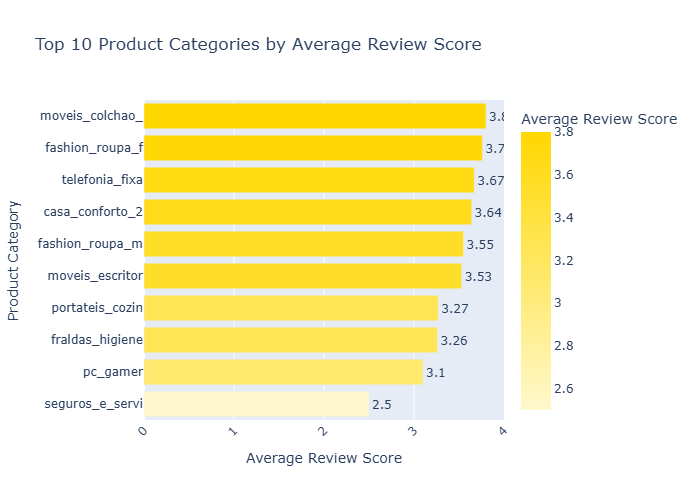

In [40]:
score_by_category = df.groupby('product_category_name')['review_score'].mean()\
    .sort_values(ascending=True).head(10).round(2).reset_index()

fig = px.bar(score_by_category, y='product_category_name', x='review_score', orientation='h',
             title='Top 10 Product Categories by Average Review Score',
             labels={'product_category_name': 'Product Category', 'review_score': 'Average Review Score'},
             text='review_score',
             color='review_score',
             color_continuous_scale=['#FFF8CC', '#FFF099', '#FFE866', '#FFE033', '#FFD700'],
             height=600, width=1200 )
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45, showlegend=False)
fig.show()

`Moveis colchao` leads with the highest average review score of 3.8, followed closely by `fashion roupa f` categories, while `eguros e servicos` has the lowest rating at 2.5, suggesting significant variation in customer satisfaction across product categories.

#### <span style='color:#ffdc73'>**Geography**</span>

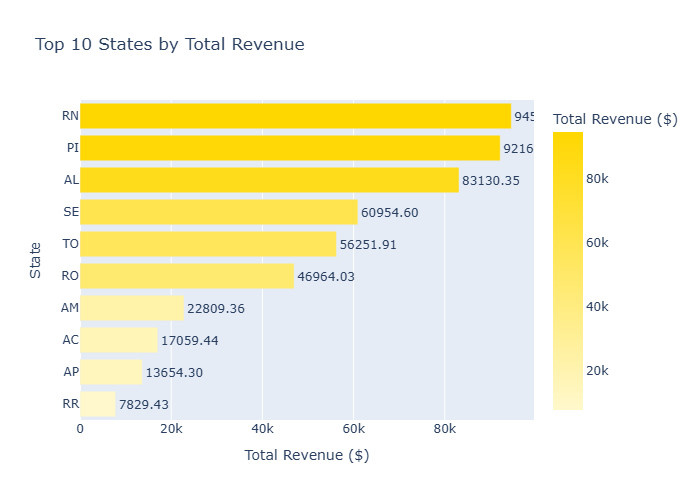

In [41]:
revenue_by_state = df.groupby('customer_state')['price'].sum().sort_values(ascending=True).head(10).reset_index()

fig = px.bar(revenue_by_state, y='customer_state', x='price', orientation='h',
             title='Top 10 States by Total Revenue',
             labels={'customer_state': 'State', 'price': 'Total Revenue ($)'},
             text='price',
             color='price',
             color_continuous_scale=['#FFF8CC', '#FFF099', '#FFE866', '#FFE033', '#FFD700'], width=1200)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

`RN` generates the highest revenue at $94594, followed by `PI` at $92168 and `AL` at $83130, while the top three states account for nearly as much revenue as the bottom seven combined.

#### <span style='color:#ffdc73'>**Correlation**</span>

Resorting to unclean kill browser.


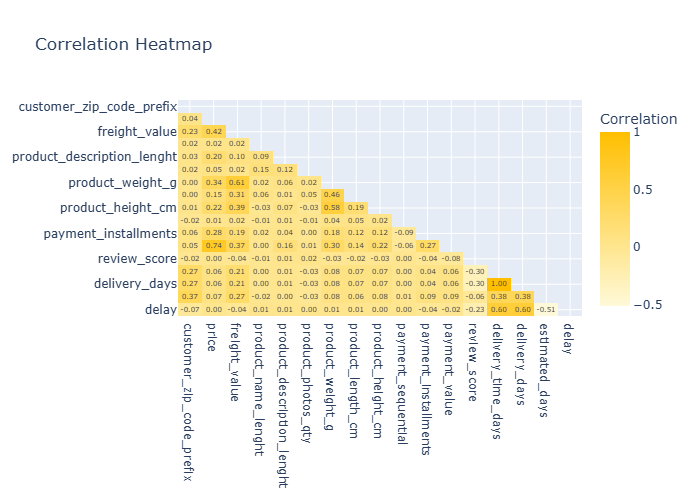

In [42]:
# Correlation

corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
corr_lower = corr.mask(mask)

fig = px.imshow(corr_lower, title='Correlation Heatmap', labels=dict(color="Correlation"),
                color_continuous_scale=["#FEF9D8", "#FFBF00"],
                aspect='auto', text_auto='.2f')
fig.update_layout(width=1200, height=800)
fig.show()

The heatmap shows that `payment_value` has the strongest correlations with `price` (0.74) and freight_value (0.37), while product dimensions (weight, length, height) show moderate correlations with each other (0.46-0.61) but weak relationships with other variables. Notably, `review_score` shows very weak correlations with all features.

# <span style='color:#ffbf00'>**Key Insights and Findings**</span>

### Platform Overview

* The dataset contains **99,140 orders**, **95,809 customers**, and **3,096 sellers**.
* Total sales value reached **20,518,016.53**, with total freight cost of **2,362,651.90**.
* Sales value and order volume show **parallel and consistent growth** from **Oct 2016 to Oct 2018**, indicating expansion driven mainly by higher transaction frequency.
* Most orders are successfully **delivered**.

### Customer Behavior & Payments

* Only **14,643 customers** placed more than one order, with an average of **1 order per customer**.
* **São Paulo (SP)** records the highest number of orders and dominates the customer base with **~40K customers**, followed by **RJ (15K)** and **MG (13K)**.
* Customers strongly prefer **credit cards (73.7%)**, followed by **boleto (19.5%)**; vouchers and debit cards play a minor role.
* Payment value decreases as installment count increases, showing installments are mainly used for **lower-value purchases**.

**What we suggest**

* We should focus on improving repeat purchase behavior, as most customers buy only once.
* Credit-card–based promotions and partnerships could further increase conversion.

### Sellers & Marketplace Structure

* Top sellers by revenue are **532_905** and **486_2b2**.
* Seller order volume does not directly match revenue ranking, reflecting **different seller business models**.
* Seller quality is consistent across the platform, with most sellers maintaining **4.0–4.5 average ratings**.

**What we suggest**

* We should encourage scalable seller models that convert high order volume into higher revenue.
* Maintaining seller quality standards appears effective and should be preserved.

### Products & Content Quality

* Most popular categories by orders are **cama mesa banho**, **beleza saude**, and **esporte lazer**.
* **cama mesa banho** leads with **9,414 orders**.
* Categories with the highest average price and freight are **pcs** and **portateis casa**.
* Most products (**48,346 orders**) use only **one photo**, with a sharp decline as photo count increases.
* Products with **5–10 photos** show stable sales, while **15+ photos** generate minimal revenue.

**What we suggest**

* We should guide sellers toward using a **moderate number of product images**, which appears to balance effort and sales performance.
* High-freight categories need pricing and logistics optimization.

### Logistics, Delivery & Reviews

* Average delivery time is **12 days**, with a **late delivery rate of 7.12%**.
* Delivery time shows **minimal impact on review scores**.
* Average review score is **4.01**, with polarized rating behavior.
* **moveis colchao** has the highest average rating (3.8), while **seguros e servicos** scores the lowest (2.5).
* States with the highest average freight value are **PB** and **RR**.
* States generating the highest revenue are **RN ($94,594)**, **PI ($92,168)**, and **AL ($83,130)**.

**What we suggest**

* We should prioritize reducing late deliveries, even though customers tolerate longer shipping times.
* Low-rated categories require quality or expectation alignment improvements.

### Growth Summary

* Month-over-month growth in orders and customers confirms effective acquisition and sustained marketplace expansion.
* New customer growth closely follows order growth, supporting long-term revenue scalability.
